# 湿草坪（ WetGrass ）贝叶斯网络：可复算的后验推断教学示例

本 Notebook 配套文档「06_贝叶斯网络经典例子.md」，用一组明确的 CPT 数值，完整走通从联合分解到枚举边际化的计算过程，复算 $P(R=T \mid W=T)$。

**说明**：数值为教学示例设定，用于演示推理计算流程。

## 学习目标

1. 明确 WetGrass 经典贝叶斯网络中的随机变量与依赖结构。
2. 理解联合分布如何按图结构分解为条件概率的乘积。
3. 使用枚举边际化复算 $P(R=T \mid W=T)$，并核对中间结果。

In [4]:
# ================== 基础设定（教学示例 CPT） ==================
# 约定：用 True/False 表示变量取值；下文用 C/R/S/W 对应 Cloudy/Rain/Sprinkler/WetGrass。

T, F = True, False

# P(Cloudy)
P_C = {
    T: 0.5,
    F: 0.5,
}

# P(Rain | Cloudy)
P_R_given_C = {
    T: {T: 0.8, F: 0.2},
    F: {T: 0.2, F: 0.8},
}

# P(Sprinkler | Cloudy)
P_S_given_C = {
    T: {T: 0.1, F: 0.9},
    F: {T: 0.5, F: 0.5},
}

# P(WetGrass | Rain, Sprinkler)
P_W_given_RS = {
    (T, T): {T: 0.99, F: 0.01},
    (T, F): {T: 0.90, F: 0.10},
    (F, T): {T: 0.90, F: 0.10},
    (F, F): {T: 0.00, F: 1.00},
}

def joint_probability(c: bool, r: bool, s: bool, w: bool) -> float:
    # 联合分解：P(C,R,S,W) = P(C) P(R|C) P(S|C) P(W|R,S)
    return P_C[c] * P_R_given_C[c][r] * P_S_given_C[c][s] * P_W_given_RS[(r, s)][w]


## 推导目标：计算 $P(R=T \mid W=T)$

按定义：

$$
P(R=T \mid W=T) = \frac{P(R=T, W=T)}{P(W=T)}
$$

其中：

$$
P(R=T, W=T) = \sum_{c \in \{T,F\}} \sum_{s \in \{T,F\}} P(C=c, R=T, S=s, W=T)
$$

$$
P(W=T) = \sum_{r \in \{T,F\}} \sum_{c \in \{T,F\}} \sum_{s \in \{T,F\}} P(C=c, R=r, S=s, W=T)
$$

In [5]:
# ================== 枚举计算：列出 W=True 的 8 种组合 ==================
# 教学要点：这里的“枚举”就是对隐变量 C 与 S（以及分母中的 R）逐项求和。

from itertools import product

rows = []
for c, r, s in product([T, F], [T, F], [T, F]):
    w = T
    p = joint_probability(c=c, r=r, s=s, w=w)
    rows.append((c, r, s, p))

def tf(x: bool) -> str:
    return "T" if x else "F"

print("(C,R,S,W=T) 的联合概率：")
for c, r, s, p in rows:
    print(f"C={tf(c)}, R={tf(r)}, S={tf(s)} => P= {p:.4f}")

(C,R,S,W=T) 的联合概率：
C=T, R=T, S=T => P= 0.0396
C=T, R=T, S=F => P= 0.3240
C=T, R=F, S=T => P= 0.0090
C=T, R=F, S=F => P= 0.0000
C=F, R=T, S=T => P= 0.0495
C=F, R=T, S=F => P= 0.0450
C=F, R=F, S=T => P= 0.1800
C=F, R=F, S=F => P= 0.0000


In [6]:
# ================== 计算分子与分母 ==================
# 分子：对 c,s 求和（固定 r=T, w=T）
# 分母：对 r,c,s 求和（固定 w=T）

numerator = 0.0
for c, s in product([T, F], [T, F]):
    numerator += joint_probability(c=c, r=T, s=s, w=T)

denominator = 0.0
for r, c, s in product([T, F], [T, F], [T, F]):
    denominator += joint_probability(c=c, r=r, s=s, w=T)

posterior = numerator / denominator

print(f"P(R=T, W=T) = {numerator:.4f}")
print(f"P(W=T)      = {denominator:.4f}")
print(f"P(R=T | W=T)= {posterior:.3f}")

P(R=T, W=T) = 0.4581
P(W=T)      = 0.6471
P(R=T | W=T)= 0.708


## 与配套文档一致的校验输出

本节输出以下信息，便于与「06_贝叶斯网络经典例子.md」逐行核对：

1. 固定 $W=T$ 时的 8 行联合概率表（含每个因子项）。
2. 分子/分母分别对应哪些行，以及数值是否与文档一致。

In [7]:
# ================== 打印与文档一致的枚举表 ==================

from itertools import product

def tf(x: bool) -> str:
    return "T" if x else "F"

def build_rows_w_true():
    table = []
    for c, r, s in product([T, F], [T, F], [T, F]):
        p_c = P_C[c]
        p_r = P_R_given_C[c][r]
        p_s = P_S_given_C[c][s]
        p_w = P_W_given_RS[(r, s)][T]
        p = p_c * p_r * p_s * p_w
        table.append({
            "C": c,
            "R": r,
            "S": s,
            "P(C)": p_c,
            "P(R|C)": p_r,
            "P(S|C)": p_s,
            "P(W=T|R,S)": p_w,
            "P(C,R,S,W=T)": p,
        })
    return table

table = build_rows_w_true()

header = [
    "#", "Cloudy", "Rain", "Sprinkler",
    "P(C)", "P(R|C)", "P(S|C)", "P(W=T|R,S)", "P(C,R,S,W=T)",
]
print(" | ".join(header))
print("-" * 110)

for i, row in enumerate(table, start=1):
    print(
        f"{i:>1} | {tf(row['C'])} | {tf(row['R'])} | {tf(row['S'])} | "
        f"{row['P(C)']:.4f} | {row['P(R|C)']:.4f} | {row['P(S|C)']:.4f} | {row['P(W=T|R,S)']:.4f} | "
        f"{row['P(C,R,S,W=T)']:.4f}"
    )

numerator_rows = [i for i, row in enumerate(table, start=1) if row["R"] is T and row["P(W=T|R,S)"] > 0]
denominator_rows = [i for i, row in enumerate(table, start=1) if row["P(W=T|R,S)"] > 0]
print("\n分子行（R=T 且 P(W=T|R,S)>0）：", numerator_rows)
print("分母行（P(W=T|R,S)>0）：", denominator_rows)

numerator_check = sum(row["P(C,R,S,W=T)"] for row in table if row["R"] is T)
denominator_check = sum(row["P(C,R,S,W=T)"] for row in table)
posterior_check = numerator_check / denominator_check
print(f"\nP(R=T, W=T) = {numerator_check:.4f}")
print(f"P(W=T)      = {denominator_check:.4f}")
print(f"P(R=T|W=T)  = {posterior_check:.3f}")

expected_numerator = 0.4581
expected_denominator = 0.6471
expected_posterior = 0.708

ok = (
    round(numerator_check, 4) == expected_numerator
    and round(denominator_check, 4) == expected_denominator
    and round(posterior_check, 3) == expected_posterior
)
print("\n与文档数值一致：" + ("PASS" if ok else "FAIL"))

# | Cloudy | Rain | Sprinkler | P(C) | P(R|C) | P(S|C) | P(W=T|R,S) | P(C,R,S,W=T)
--------------------------------------------------------------------------------------------------------------
1 | T | T | T | 0.5000 | 0.8000 | 0.1000 | 0.9900 | 0.0396
2 | T | T | F | 0.5000 | 0.8000 | 0.9000 | 0.9000 | 0.3240
3 | T | F | T | 0.5000 | 0.2000 | 0.1000 | 0.9000 | 0.0090
4 | T | F | F | 0.5000 | 0.2000 | 0.9000 | 0.0000 | 0.0000
5 | F | T | T | 0.5000 | 0.2000 | 0.5000 | 0.9900 | 0.0495
6 | F | T | F | 0.5000 | 0.2000 | 0.5000 | 0.9000 | 0.0450
7 | F | F | T | 0.5000 | 0.8000 | 0.5000 | 0.9000 | 0.1800
8 | F | F | F | 0.5000 | 0.8000 | 0.5000 | 0.0000 | 0.0000

分子行（R=T 且 P(W=T|R,S)>0）： [1, 2, 5, 6]
分母行（P(W=T|R,S)>0）： [1, 2, 3, 5, 6, 7]

P(R=T, W=T) = 0.4581
P(W=T)      = 0.6471
P(R=T|W=T)  = 0.708

与文档数值一致：PASS


## 可视化（可选）

若环境已安装 `matplotlib`，则绘制每一行对 $P(W=T)$ 的贡献，以及 $P(W=T \mid R,S)$ 的 2×2 结构。

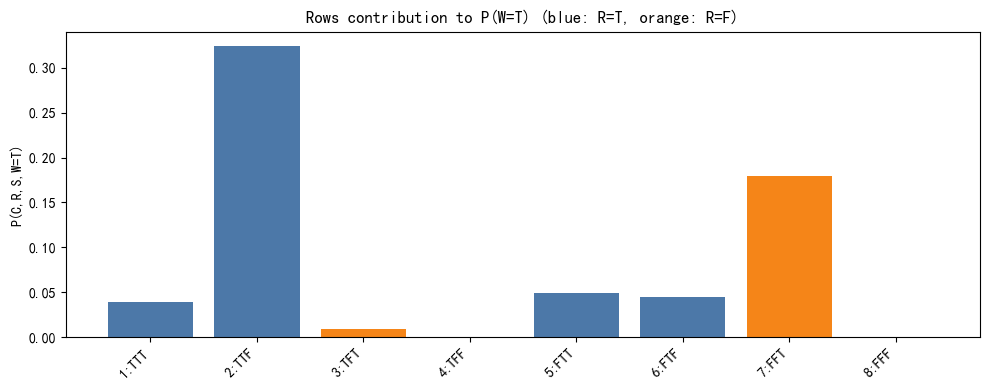

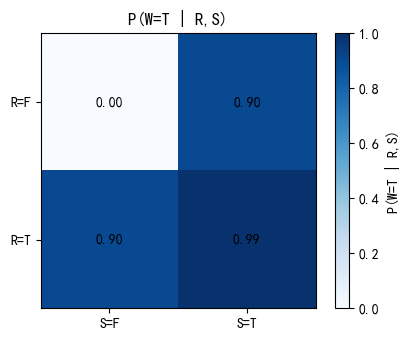

In [8]:
# ================== 可视化输出（需要 matplotlib） ==================

try:
    import matplotlib.pyplot as plt
except Exception as e:
    print("未检测到 matplotlib，跳过可视化。原因：", repr(e))
else:
    labels = [f"{i}:{tf(row['C'])}{tf(row['R'])}{tf(row['S'])}" for i, row in enumerate(table, start=1)]
    values = [row["P(C,R,S,W=T)"] for row in table]
    colors = ["#4C78A8" if row["R"] is T else "#F58518" for row in table]

    plt.figure(figsize=(10, 4))
    plt.bar(labels, values, color=colors)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("P(C,R,S,W=T)")
    plt.title("Rows contribution to P(W=T) (blue: R=T, orange: R=F)")
    plt.tight_layout()
    plt.show()

    heat = [
        [P_W_given_RS[(F, F)][T], P_W_given_RS[(F, T)][T]],
        [P_W_given_RS[(T, F)][T], P_W_given_RS[(T, T)][T]],
    ]
    plt.figure(figsize=(4.5, 3.5))
    plt.imshow(heat, cmap="Blues", vmin=0.0, vmax=1.0)
    plt.colorbar(label="P(W=T | R,S)")
    plt.xticks([0, 1], ["S=F", "S=T"])
    plt.yticks([0, 1], ["R=F", "R=T"])
    plt.title("P(W=T | R,S)")
    for y in range(2):
        for x in range(2):
            plt.text(x, y, f"{heat[y][x]:.2f}", ha="center", va="center", color="black")
    plt.tight_layout()
    plt.show()

## 结果解读

你会看到后验概率约为 $0.708$。在该示例设定下，观测到草坪湿（$W=T$）后，下雨（$R=T$）变得更可能，这是因为：

1. 多云会提高下雨概率。
2. 下雨与洒水器都能导致草坪湿，但当洒水器关闭时仍可能因下雨变湿。
3. 枚举边际化在数值上把所有可能的“解释路径”都考虑进来了。